# 🎬 Movie Recommendation System - 6 Engines
## Phase 1: Data Exploration & Preprocessing

**Objective:**  
Load the raw movie metadata and ratings data, inspect their structure, identify missing values, and gain initial insights to guide the next steps.

**Data Sources:**  
- `movies_data.csv` → Contains 6000 movies with metadata (title, overview, genres, etc.)
- `ratings.csv` → Contains 100k+ user ratings with timestamps
- `posters/` folder → 5983 movie poster images (extracted from `posters.rar`)

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style('whitegrid')
%matplotlib inline

# Define paths relative to this notebook
# The notebook is inside 'notebooks/' folder, so we go up one level to reach project root
BASE_DIR = os.path.dirname(os.getcwd())  # This will be 'Movie_Recommender_System'
RAW_DATA_DIR = os.path.join(BASE_DIR, 'data', 'raw')
POSTERS_DIR = os.path.join(BASE_DIR, 'data', 'posters')

# Verify paths
print("Base directory:", BASE_DIR)
print("Raw data directory:", RAW_DATA_DIR)
print("Posters directory:", POSTERS_DIR)

Base directory: C:\Users\Saeed\Desktop\Movie_Recommendetion_System
Raw data directory: C:\Users\Saeed\Desktop\Movie_Recommendetion_System\data\raw
Posters directory: C:\Users\Saeed\Desktop\Movie_Recommendetion_System\data\posters


In [2]:
# Load movies metadata
movies_file = os.path.join(RAW_DATA_DIR, 'movies_data.csv')
df_movies = pd.read_csv(movies_file)
print(f"✅ Loaded movies_data.csv: {df_movies.shape[0]} rows, {df_movies.shape[1]} columns")

# Load ratings
ratings_file = os.path.join(RAW_DATA_DIR, 'ratings.csv')
df_ratings = pd.read_csv(ratings_file)
print(f"✅ Loaded ratings.csv: {df_ratings.shape[0]} rows, {df_ratings.shape[1]} columns")

✅ Loaded movies_data.csv: 6000 rows, 11 columns
✅ Loaded ratings.csv: 100836 rows, 4 columns


In [3]:
# Display first few rows of movies
df_movies.head()

,movie_id,title,overview,genres,director,cast,rating,vote_count,popularity,release_date,poster_path
0,1523145,Your Heart Will Be Broken,High school student Polina is saved from bully...,"[10749, 18]",Mikhail Vaynberg,"Daniel Vegas, Veronika Zhuravleva, Ivan Trushi...",7.045,56,849.4288,2026-03-26,posters/1523145.jpg
1,83533,Avatar: Fire and Ash,In the wake of the devastating war against the...,"[878, 12, 14]",James Cameron,"Sam Worthington, Zoe Saldaña, Sigourney Weaver...",7.400,2531,354.1924,2025-12-17,posters/83533.jpg
2,1327819,Hoppers,Scientists have discovered how to 'hop' human ...,"[16, 10751, 878, 35, 12]",Daniel Chong,"Piper Curda, Bobby Moynihan, Jon Hamm, Kathy N...",7.582,451,349.1407,2026-03-04,posters/1327819.jpg
3,502356,The Super Mario Bros. Movie,"While working underground to fix a water main,...","[10751, 35, 12, 14, 16]",Aaron Horvath,"Chris Pratt, Anya Taylor-Joy, Charlie Day, Jac...",7.588,10469,339.0067,2023-04-05,posters/502356.jpg
4,1226863,The Super Mario Galaxy Movie,Having thwarted Bowser's previous plot to marr...,"[10751, 35, 12, 14, 16]",Michael Jelenic,"Chris Pratt, Charlie Day, Anya Taylor-Joy, Jac...",6.800,403,274.0615,2026-04-01,posters/1226863.jpg


In [4]:
# Info about columns and null counts
print("=== Movies DataFrame Info ===")
df_movies.info()

print("\n=== Null Values Count ===")
print(df_movies.isnull().sum())

=== Movies DataFrame Info ===
<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   movie_id      6000 non-null   int64  
 1   title         6000 non-null   str    
 2   overview      5963 non-null   str    
 3   genres        6000 non-null   str    
 4   director      6000 non-null   str    
 5   cast          5977 non-null   str    
 6   rating        6000 non-null   float64
 7   vote_count    6000 non-null   int64  
 8   popularity    6000 non-null   float64
 9   release_date  5990 non-null   str    
 10  poster_path   5986 non-null   str    
dtypes: float64(2), int64(2), str(7)
memory usage: 515.8 KB

=== Null Values Count ===
movie_id         0
title            0
overview        37
genres           0
director         0
cast            23
rating           0
vote_count       0
popularity       0
release_date    10
poster_path     14
dtype: int64


In [5]:
# Descriptive statistics for numerical columns
df_movies.describe()

,movie_id,rating,vote_count,popularity
count,6.000000e+03,6000.000000,6000.000000,6000.000000
mean,3.957298e+05,6.520382,2779.256500,7.799570
std,4.723377e+05,1.395830,4153.870041,18.742297
min,1.100000e+01,0.000000,0.000000,1.465600
25%,1.066375e+04,6.136000,211.000000,3.756525
50%,1.619470e+05,6.715500,1321.500000,4.774150
75%,6.627072e+05,7.300000,3501.250000,7.112200
max,1.665757e+06,10.000000,39355.000000,849.428800


In [6]:
# Check genres column - sample values and missing
print("Sample genres:")
print(df_movies['genres'].head(10))
print("\nUnique genre strings count:", df_movies['genres'].nunique())

Sample genres:
0                 [10749, 18]
1               [878, 12, 14]
2    [16, 10751, 878, 35, 12]
3     [10751, 35, 12, 14, 16]
4     [10751, 35, 12, 14, 16]
5                [28, 80, 53]
6                    [80, 53]
7                   [878, 12]
8                    [27, 53]
9               [12, 53, 878]
Name: genres, dtype: str

Unique genre strings count: 1638


In [7]:
# Display first few ratings
df_ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [8]:
print("=== Ratings DataFrame Info ===")
df_ratings.info()

print("\n=== Null Values Count ===")
print(df_ratings.isnull().sum())

print("\n=== Basic Statistics ===")
print(df_ratings.describe())

=== Ratings DataFrame Info ===
<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB

=== Null Values Count ===
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

=== Basic Statistics ===
              userId        movieId         rating     timestamp
count  100836.000000  100836.000000  100836.000000  1.008360e+05
mean      326.127564   19435.295718       3.501557  1.205946e+09
std       182.618491   35530.987199       1.042529  2.162610e+08
min         1.000000       1.000000       0.500000  8.281246e+08
25%       177.000000    1199.000000       3.000000  1.019124e+09
50%       325.000000    2991.000000       3.500000  1.1860

In [9]:
n_users = df_ratings['userId'].nunique()
n_movies_rated = df_ratings['movieId'].nunique()
print(f"Number of unique users: {n_users}")
print(f"Number of unique movies rated: {n_movies_rated}")
print(f"Total ratings: {len(df_ratings)}")
print(f"Sparsity: {len(df_ratings) / (n_users * n_movies_rated):.4%}")

Number of unique users: 610
Number of unique movies rated: 9724
Total ratings: 100836
Sparsity: 1.7000%


C:\Users\Saeed\AppData\Local\Temp\ipykernel_16572\778203743.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_ratings, x='rating', palette='viridis')


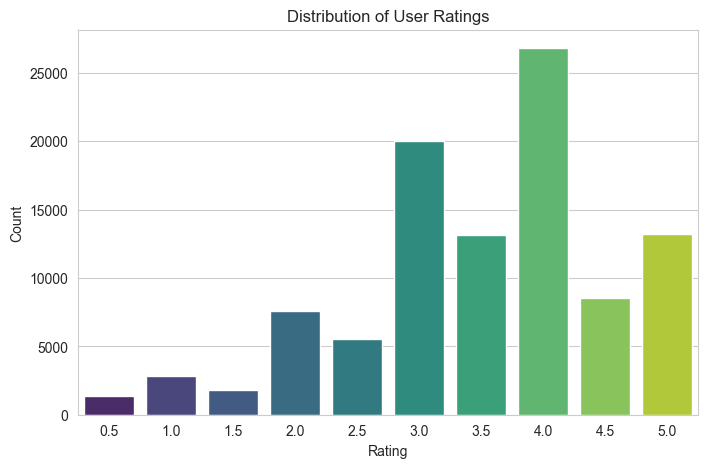

In [10]:
# Distribution of rating values
plt.figure(figsize=(8,5))
sns.countplot(data=df_ratings, x='rating', palette='viridis')
plt.title('Distribution of User Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [11]:
# Check posters folder
if os.path.exists(POSTERS_DIR):
    poster_files = [f for f in os.listdir(POSTERS_DIR) if f.endswith(('.jpg','.png','.jpeg'))]
    print(f"✅ Posters folder found with {len(poster_files)} images.")
else:
    print(f"⚠️ Posters folder not found at: {POSTERS_DIR}")

# Cross-check with poster_path column
df_movies['poster_exists'] = df_movies['poster_path'].apply(
    lambda x: os.path.exists(os.path.join(BASE_DIR, x)) if isinstance(x, str) else False
)
print(f"Movies with valid poster file (according to CSV): {df_movies['poster_exists'].sum()} / {len(df_movies)}")

✅ Posters folder found with 5983 images.
Movies with valid poster file (according to CSV): 0 / 6000


## 📊 Key Observations

- **Movies data:** 6000 movies, with some missing values in `overview` (37), `cast` (23), `release_date` (10), and `poster_path` (14). These are minimal and can be handled easily.
- **Ratings data:** 100,836 ratings from 610 users on 9,724 movies. The rating scale is from 0.5 to 5.0, with integer steps most common.
- **Sparsity:** The rating matrix is extremely sparse (~1.7%), which is typical for recommendation systems.
- **Posters:** 5,983 posters are physically present; 14 movies lack a poster path. We'll keep only movies with existing posters for the visual engine.

**Next Steps:**  
Proceed to clean the text data, fill missing overviews, and build the first recommendation engine (Content-Based).